# Coral Conundrum

**Category:** Data Storytelling  
**Datasets:** 5 linked files - word trends, bleaching reefs, coral cover,
SCUBA certifications, fish identification book  
**Objective:** Investigate why coral reef fish word usage dropped sharply
around 1998, testing three competing explanations.

---

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append('..')
from src.linear_model import LinearModel

words = pd.read_csv('../data/animal-word-trends-coral-conundrum.csv')
bleaching = pd.read_csv('../data/bleaching-reefs.csv')
coral = pd.read_csv('../data/global-coral-cover.csv')
scuba = pd.read_csv('../data/new-scuba-certifications.csv')
fish_id = pd.read_csv('../data/reef-fish-identification-book.csv')

words.head()

,year,word,frequency
0,1900,angelfish,0.003158
1,1900,bannerfish,0.000015
2,1900,blenny,0.052464
3,1900,butterflyfish,0.000232
4,1900,damselfish,0.000000


## 1. Dataset Exploration

Five separate files with five different shapes. Exploring each
independently before attempting any cross-dataset comparison.

In [3]:
print("=== WORDS ===")
print("Shape:", words.shape)
print("Unique words:", words['word'].nunique())
print(sorted(words['word'].unique()))
print()

print("=== BLEACHING ===")
print("Shape:", bleaching.shape)
print("Severity value count:")
print(bleaching['severity'].value_counts())
print()

print("=== CORAL COVER ===")
print("Shape:", coral.shape)
print()

print("=== SCUBA ===")
print("Shape:", scuba.shape)
print()

print("=== FISH ID BOOK ===")
print("Shape:", fish_id.shape)
print()

=== WORDS ===
Shape: (3133, 3)
Unique words: 27
['anemonefish', 'angelfish', 'bannerfish', 'blenny', 'butterflyfish', 'cornetfish', 'damselfish', 'filefish', 'frogfish', 'goatfish', 'hawkfish', 'lionfish', 'lizardfish', 'needlefish', 'parrotfish', 'pipefish', 'porcupinefish', 'rabbitfish', 'scorpionfish', 'sharksucker', 'soldierfish', 'squirrelfish', 'surgeonfish', 'triggerfish', 'trumpetfish', 'unicornfish', 'wrasse']

=== BLEACHING ===
Shape: (609, 3)
Severity value count:
severity
M     277
S     262
S      37
M      32
c       1
Name: count, dtype: int64

=== CORAL COVER ===
Shape: (39, 2)

=== SCUBA ===
Shape: (45, 2)

=== FISH ID BOOK ===
Shape: (27, 2)



## 2. Exploring Species Trends Over Time

Creating a reusable plotting function to compare word-frequency trends
across multiple reef fish species and determine whether the decline
around 1998 is widespread rather than limited to a single species.

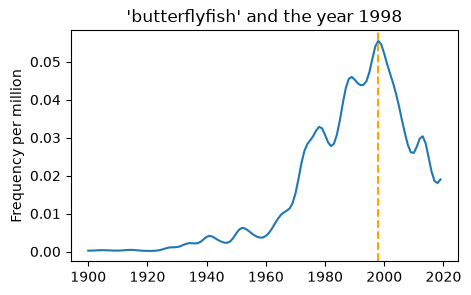

In [4]:
def plot_word_trend(animal):
    trend = words.query('word == @animal')
    plt.figure(figsize=(5, 3))
    plt.plot(trend['year'], trend['frequency'])
    plt.ylabel('Frequency per million')
    plt.title(f"'{animal}' and the year 1998")
    plt.axvline(1998, color='orange', ls='--')
    plt.show()

plot_word_trend('butterflyfish')

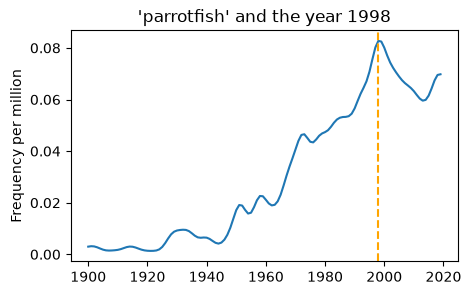

In [5]:
plot_word_trend('parrotfish')

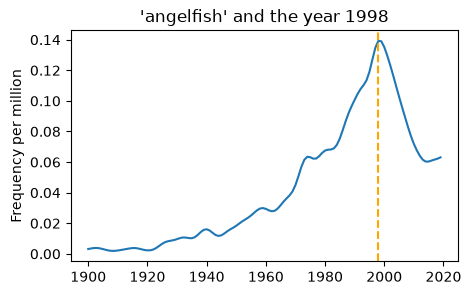

In [6]:
plot_word_trend('angelfish')

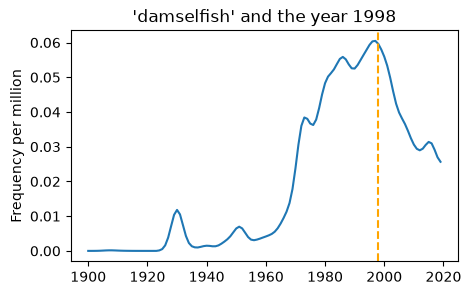

In [7]:
plot_word_trend('damselfish')

## 3. Mechanism 1 - Cleaning the Bleaching Dataset

Cleaning the bleaching severity labels before analysis to ensure
consistent category counts. Standardizing the values prevents
inconsistent text entries from producing misleading summary statistics.

In [8]:
bleaching['severity'].value_counts()

severity
M     277
S     262
S      37
M      32
c       1
Name: count, dtype: int64

In [9]:
bleaching['severity'] = bleaching['severity'].str.strip()
bleaching['severity'].value_counts()

severity
M    309
S    299
c      1
Name: count, dtype: int64

In [10]:
bleaching[bleaching['severity'] == 'c']

,location,year,severity
46,"Australia, South West Rocks",1985,c


One record contained an unrecoverable bleaching severity label (`'c'`).
Because its correct value could not be determined reliably, the record
was removed before calculating yearly bleaching statistics.

In [11]:
# drop the unrecoverable column, documented

bleaching_clean = bleaching[bleaching['severity'] != 'c'].copy()
print(f"Drop 1 row with unrecoverable severity code out of {len(bleaching)} total.")
print(f"Remaining rows: {len(bleaching_clean)}")

Drop 1 row with unrecoverable severity code out of 609 total.
Remaining rows: 608


## 4. Mechanism 1 - Bleaching Events Over Time

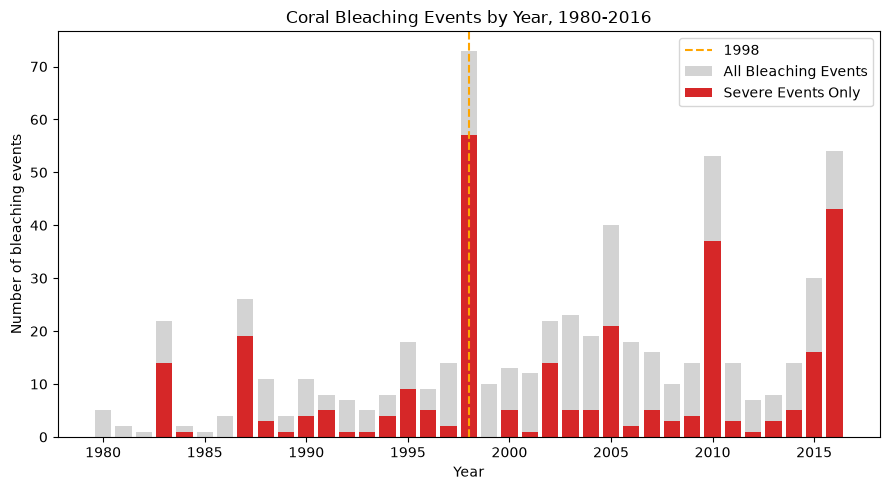

Chart Saved.


In [12]:
events_per_year = bleaching_clean.groupby('year').size()
severe_per_year = bleaching_clean.query("severity == 'S'").groupby('year').size()

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(
    events_per_year.index,
    events_per_year.values,
    color='lightgray',
    label='All Bleaching Events'
)
ax.bar(
    severe_per_year.index,
    severe_per_year.values,
    color='C3',
    label='Severe Events Only'
)
ax.axvline(
    1998,
    color='orange',
    ls='--',
    label='1998'
)

ax.set_xlabel('Year')
ax.set_ylabel('Number of bleaching events')
ax.set_title('Coral Bleaching Events by Year, 1980-2016')
ax.legend()
plt.tight_layout()

plt.savefig('../images/plots/bleaching_events_by_year.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart Saved.")

## 5. Mechanism 1 - Comparing Trends Over Time

Comparing coral cover, SCUBA certifications, and reef fish word
frequency on a shared timeline to examine whether changes around 1998
occur together across the three datasets.

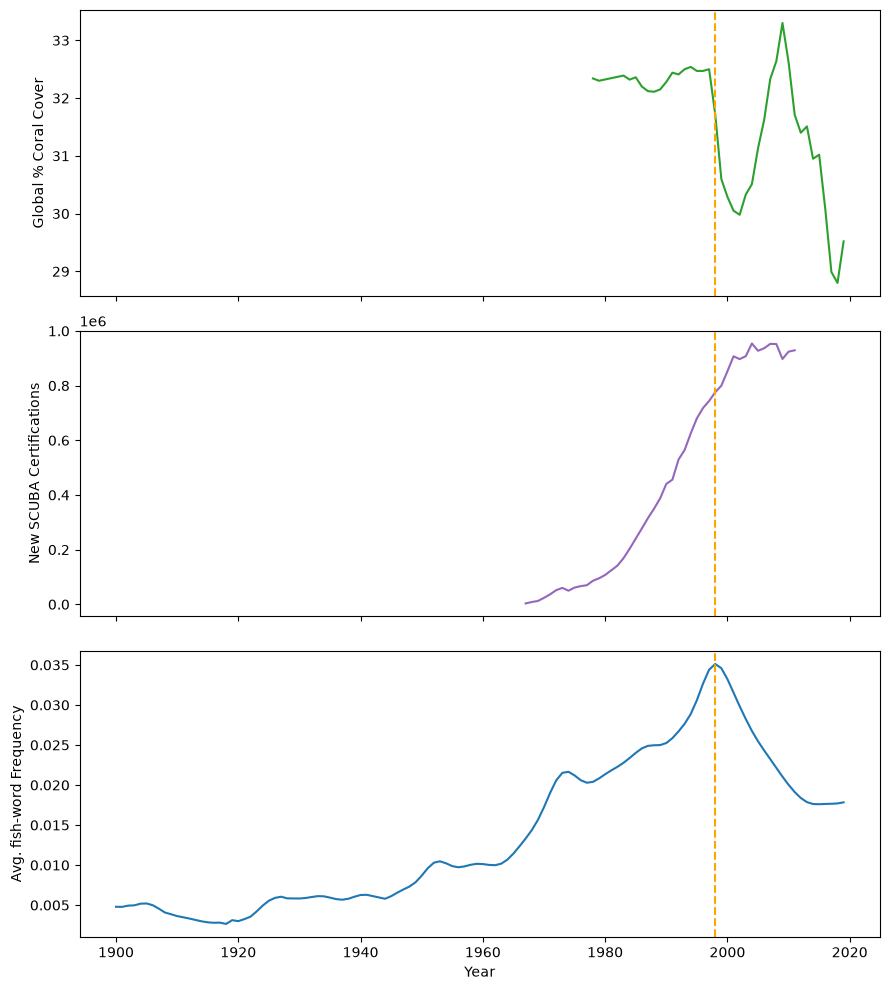

Chart Saved.


In [13]:
fig, axes = plt.subplots(3, 1, figsize=(9, 10), sharex=True)

axes[0].plot(coral['year'], coral['percent_coral'], color='C2')
axes[0].axvline(1998, color='orange', ls='--')
axes[0].set_ylabel('Global % Coral Cover')

axes[1].plot(scuba['year'], scuba['num_new_certifications'], color='C4')
axes[1].axvline(1998, color='orange', ls='--')
axes[1].set_ylabel('New SCUBA Certifications')

avg_word_freq = words.groupby('year')['frequency'].mean()

axes[2].plot(avg_word_freq.index, avg_word_freq.values, color='C0')
axes[2].axvline(1998, color='orange', ls='--')
axes[2].set_ylabel('Avg. fish-word Frequency')
axes[2].set_xlabel('Year')

plt.tight_layout()

plt.savefig('../images/plots/three_panel_cooccurrence.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart Saved.")

## 6. Mechanism 2 - The Internet/Identification-Book Effect

Testing whether fish names with more species coverage in a 2005
identification book also had higher word frequency specifically in 1998.

In [14]:
freq_1998 = words.query('year == 1998')[['word', 'frequency']]

merged = freq_1998.merge(fish_id, on='word')
print("Merged Shape:", merged.shape)
merged.head()

Merged Shape: (27, 3)


,word,frequency,num_species_in_book
0,anemonefish,0.024134,20
1,angelfish,0.139240,49
2,bannerfish,0.004208,7
3,blenny,0.078351,64
4,butterflyfish,0.055496,63


LinearModel(Book species count -> 1998 word frequency):
Slope: 0.0010183062587083547
Intercept: 0.007997103703284922
R-squared: 0.6573764148175836


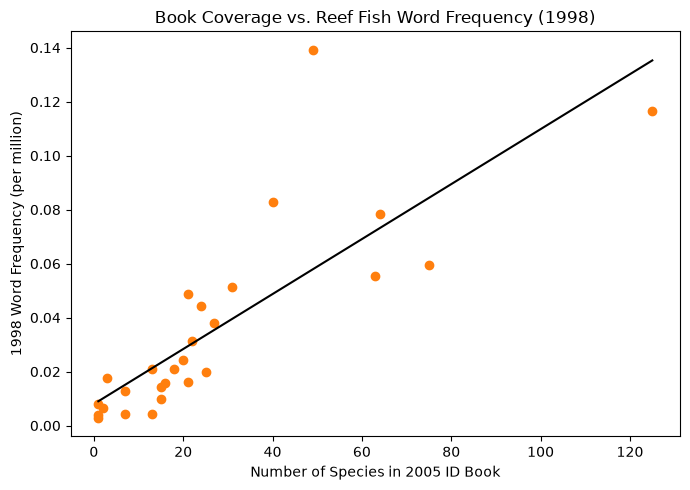

Chart saved.


In [17]:
book_model = LinearModel(model_name='Book species count -> 1998 word frequency')
book_model.fit(merged['num_species_in_book'], merged['frequency'])
book_model.print_model_info()

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(merged['num_species_in_book'], merged['frequency'], color='C1')
book_model.plot_model(merged['num_species_in_book'].min(), merged['num_species_in_book'].max())
ax.set_xlabel('Number of Species in 2005 ID Book')
ax.set_ylabel('1998 Word Frequency (per million)')
ax.set_title('Book Coverage vs. Reef Fish Word Frequency (1998)')
plt.tight_layout()

plt.savefig('../images/plots/book_coverage_vs_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved.")

## 7. Mechanism 3 - Exploring an Alternative Explanation

Considering whether the decline after 1998 reflects a broader reduction
in specialized nature and zoology vocabulary rather than a change
specific to coral reef fish. While this hypothesis cannot be fully
tested with the available data, proposing plausible alternative
explanations is an important part of the analytical process.

In [16]:
peak_year_per_word = words.loc[words.groupby('word')['frequency'].idxmax()][['word', 'year', 'frequency']]
peak_year_per_word.columns = ['word', 'peak_year', 'peak_frequency']

freq_2015 = words.query('year == 2015')[['word', 'frequency']]
freq_2015.columns = ['word', 'frequency_2015']

decline_table = peak_year_per_word.merge(freq_2015, on='word')
decline_table['pct_decline'] = (
    (decline_table['peak_frequency'] - decline_table['frequency_2015'])
    / decline_table['peak_frequency'] * 100
)

decline_table.sort_values('pct_decline', ascending=False)

,word,peak_year,peak_frequency,frequency_2015,pct_decline
20,soldierfish,1998,0.009948,0.002455,75.321673
13,needlefish,1971,0.028703,0.008005,72.110929
24,trumpetfish,1997,0.008133,0.002432,70.097135
10,hawkfish,1999,0.014415,0.004324,70.003469
16,porcupinefish,1999,0.006497,0.001975,69.601354
21,squirrelfish,1998,0.020792,0.006482,68.824548
2,bannerfish,1998,0.004208,0.001318,68.678707
5,cornetfish,1998,0.003866,0.001217,68.520435
9,goatfish,1985,0.033171,0.010715,67.697688
12,lizardfish,1982,0.014514,0.004836,66.680446


## 8. Key Insights

- Reef fish word frequency declined substantially after **1998**, coinciding
  with increasing coral bleaching events and declining coral cover.
  This provides **moderate evidence** that reef degradation may have
  contributed to reduced public attention.

- Fish appearing in more identification books generally had higher word frequencies in **1998**, with the regression model showing a **moderately strong positive relationship (R² ≈ 0.66)** suggesting that educational exposure through identification books may partially influence public familiarity with reef fish.

- Most reef fish words declined substantially from their historical peak to **2015**, suggesting the observed pattern is widespread rather than limited to a few species.

- No single mechanism fully explains the decline. The available evidence suggests that **multiple factors**, including reef degradation, educational exposure, and broader publishing trends, likely contributed together.

- This project demonstrates the importance of evaluating **multiple competing hypotheses** and drawing conclusions based only on the evidence available, rather than assuming a single cause.